## Importar librerias

In [1]:
import pandas as pd

In [2]:
# Carga de datos
application_train = pd.read_csv("../Data/raw/application_train.csv")
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## EDA

In [3]:
# shape del dataset
application_train.shape

(307511, 122)

In [4]:
application_train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            str    
 3    CODE_GENDER                   str    
 4    FLAG_OWN_CAR                  str    
 5    FLAG_OWN_REALTY               str    
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               str    
 12   NAME_INCOME_TYPE              str    
 13   NAME_EDUCATION_TYPE           str    
 14   NAME_FAMILY_STATUS            str    
 15   NAME_HOUSING_TYPE             str    
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS_EMPLOYED

In [22]:
# Conteo de valores nulos en total
nulls = application_train.isnull().sum()

# Porcentaje de valores nulos por columna
nulls_pct = (nulls / len(application_train) * 100).round(2)

# Guardamos un reporte de los valores nulos por columna
null_report = (pd.DataFrame({'nulos': nulls, 'porcentaje': nulls_pct})).query('nulos > 0').sort_values('porcentaje',ascending=False)

null_report

,nulos,porcentaje
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


In [ ]:
null_report[null_report['porcentaje'] > 40]

,nulos,porcentaje
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


In [7]:
# Analisis de TARGET
target_counts = application_train['TARGET'].value_counts()
target_pct = application_train['TARGET'].value_counts(normalize=True) * 100

print('Conteo de observaciones en TARGET\n', target_counts)
print('\nPorcentaje de cada valor\n', target_pct.round(2))

Conteo de observaciones en TARGET
 TARGET
0    282686
1     24825
Name: count, dtype: int64

Porcentaje de cada valor
 TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


/tmp/ipykernel_5684/57334752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=application_train, ax=ax, palette='deep')


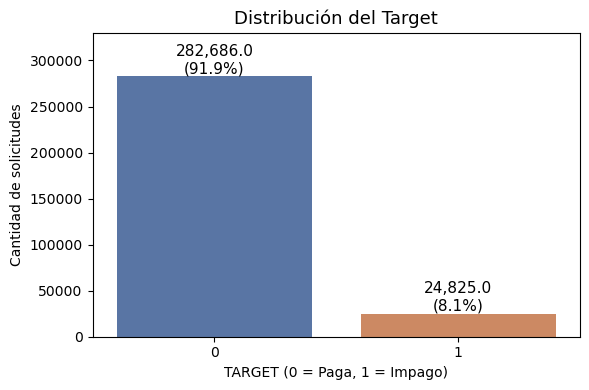

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6,4))

sns.countplot(x='TARGET', data=application_train, ax=ax, palette='deep')

ax.set_title('Distribución del Target', fontsize=13)
ax.set_xlabel('TARGET (0 = Paga, 1 = Impago)')
ax.set_ylabel('Cantidad de solicitudes')
ax.set_ylim(0, 330000)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(application_train)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom', fontsize=11)
    
plt.tight_layout()
plt.savefig('../Reports/figures/01_target_distribution.png', dpi=150)
plt.show()

In [9]:
# Análisis de variables numéricas
application_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


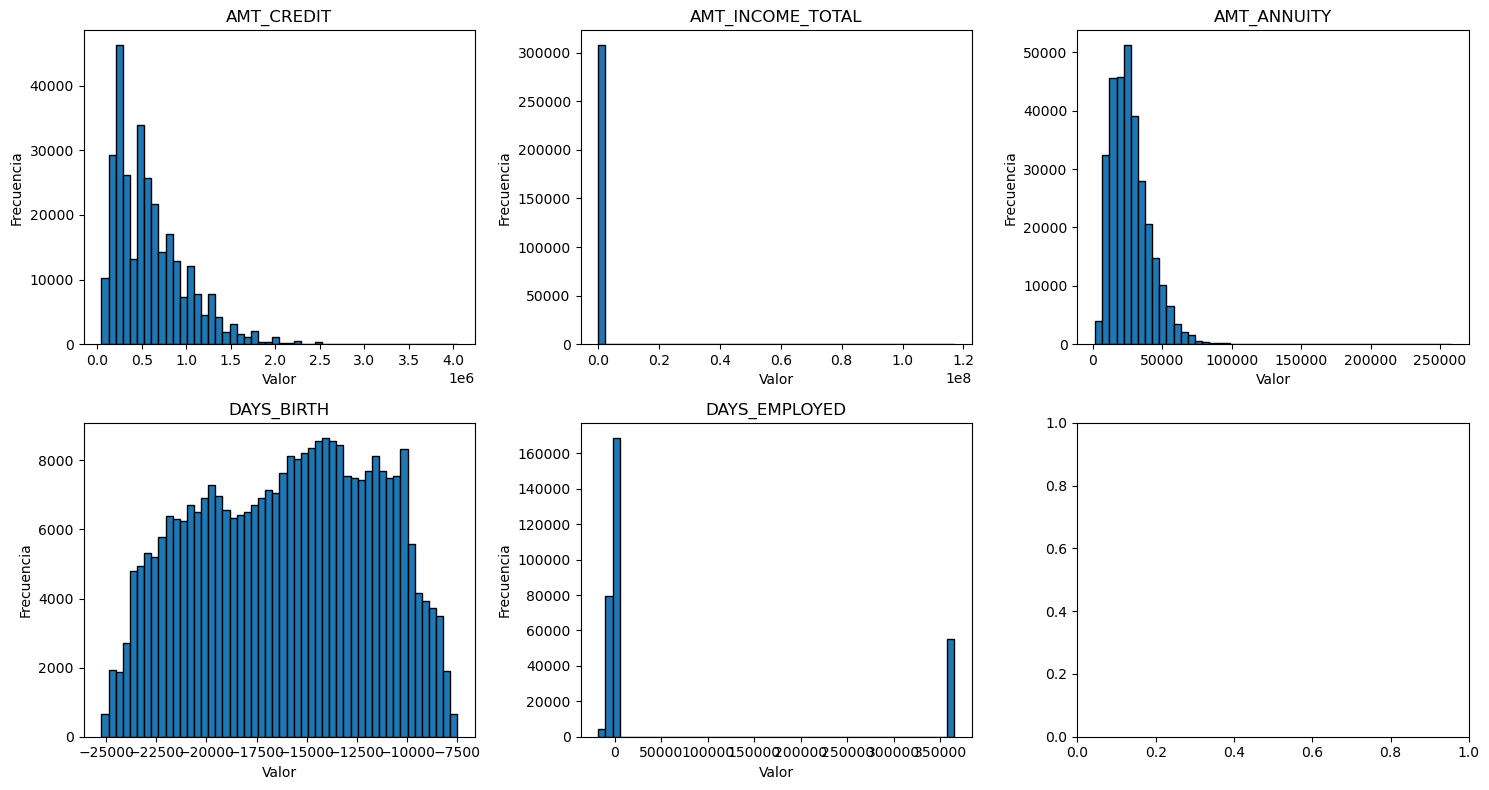

In [10]:
cols_interes = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_interes):
    axes[i].hist(application_train[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    
plt.tight_layout()
plt.savefig('../Reports/figures/02_numeric_distributions.png')
plt.show()

In [11]:
# Analisis de valores anomalos en DAYS_EMPLOYED
application_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [12]:
application_train['DAYS_EMPLOYED'].max()

np.int64(365243)

In [13]:
# Total de observaciones con valor maximo
total_cod = (application_train['DAYS_EMPLOYED'] == 365243).sum()
total_cod

np.int64(55374)

In [14]:
# Porcentaje de observaciones con valor maximo
cod_report = (total_cod / len(application_train) * 100).round(2)
print(cod_report)

18.01


In [15]:
# Analisis de AMT_INCOME_TOTAL
application_train['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [16]:
# Cantidad de clientes con ingresos por encima de un umbral
print(f'Clientes con ingresos mayores a 1 millón: {(application_train['AMT_INCOME_TOTAL'] > 1_000_000).sum()}\n')
print(f'Clientes con ingresos mayores a 10 millones: {(application_train['AMT_INCOME_TOTAL'] > 10_000_000).sum()}\n')

Clientes con ingresos mayores a 1 millón: 250

Clientes con ingresos mayores a 10 millones: 3



In [17]:
# Analisis de variables categoricas
cat_cols = application_train.select_dtypes(include='str').columns.tolist()
print(cat_cols)
print(f'\nTotal: {len(cat_cols)} variables categóricas')

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Total: 16 variables categóricas


In [18]:
# Valores unicos en cara variable
for col in cat_cols:
    print(f"{col}: {application_train[col].nunique()} valores únicos")

NAME_CONTRACT_TYPE: 2 valores únicos
CODE_GENDER: 3 valores únicos
FLAG_OWN_CAR: 2 valores únicos
FLAG_OWN_REALTY: 2 valores únicos
NAME_TYPE_SUITE: 7 valores únicos
NAME_INCOME_TYPE: 8 valores únicos
NAME_EDUCATION_TYPE: 5 valores únicos
NAME_FAMILY_STATUS: 6 valores únicos
NAME_HOUSING_TYPE: 6 valores únicos
OCCUPATION_TYPE: 18 valores únicos
WEEKDAY_APPR_PROCESS_START: 7 valores únicos
ORGANIZATION_TYPE: 58 valores únicos
FONDKAPREMONT_MODE: 4 valores únicos
HOUSETYPE_MODE: 3 valores únicos
WALLSMATERIAL_MODE: 7 valores únicos
EMERGENCYSTATE_MODE: 2 valores únicos


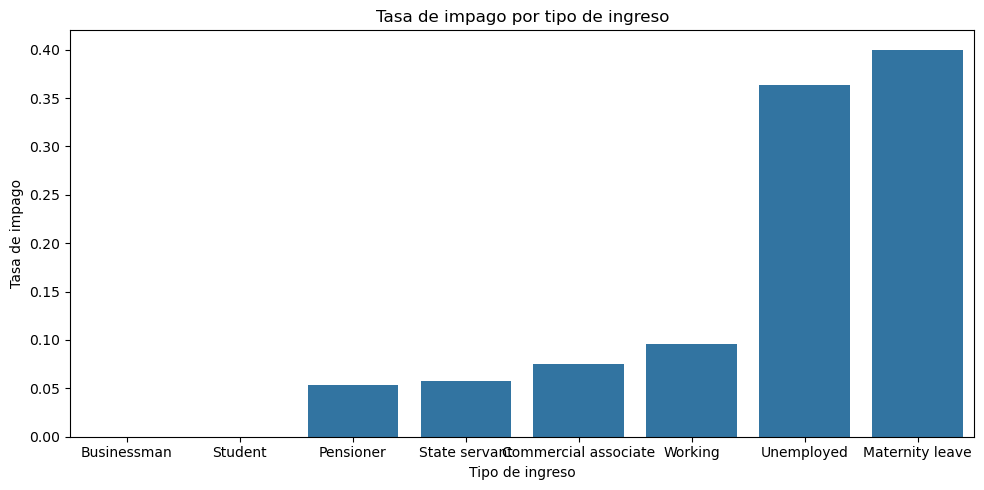

In [19]:
# Relacion entre categoricas y el target
fig, ax = plt.subplots(figsize=(10,5))

tasa_impago = (
    application_train.groupby('NAME_INCOME_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

sns.barplot(data=tasa_impago, x='NAME_INCOME_TYPE', y='TARGET', ax=ax)

ax.set_title('Tasa de impago por tipo de ingreso')
ax.set_xlabel('Tipo de ingreso')
ax.set_ylabel('Tasa de impago')

plt.tight_layout()
plt.savefig('../Reports/figures/03_impago_por_tipo_ingreso.png')
plt.show()

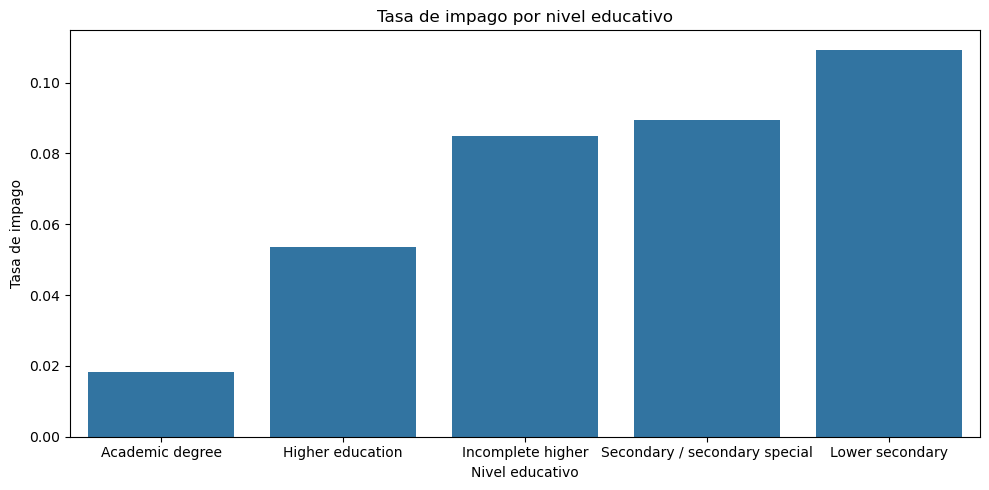

In [20]:
fig, ax = plt.subplots(figsize=(10,5))

tasa_impago = (
    application_train.groupby('NAME_EDUCATION_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

sns.barplot(data=tasa_impago, x='NAME_EDUCATION_TYPE', y='TARGET', ax=ax)

ax.set_title('Tasa de impago por nivel educativo')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Tasa de impago')

plt.tight_layout()
plt.savefig('../Reports/figures/04_impago_por_nivel_educativo.png')
plt.show()

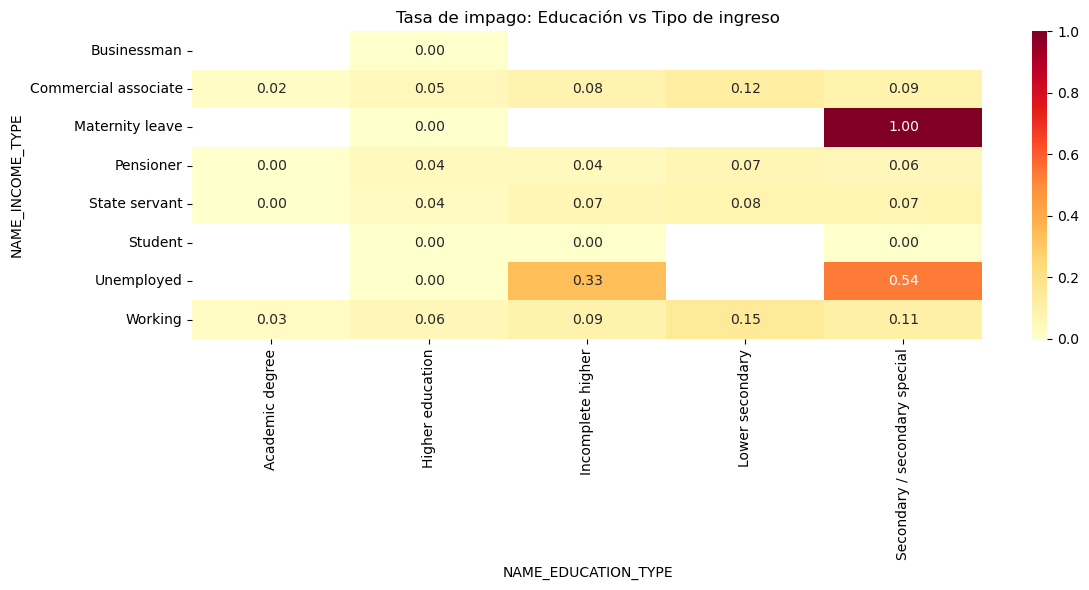

In [21]:
fig, ax = plt.subplots(figsize=(12,6))

cross = (application_train.groupby(['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'])['TARGET']
         .mean()
         .unstack())

sns.heatmap(cross, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)

ax.set_title('Tasa de impago: Educación vs Tipo de ingreso')
plt.tight_layout()
plt.savefig('../Reports/figures/05_impago_educacion_vs_ingreso.png')
plt.show()

# Uso de DuckDB

In [22]:
import duckdb

con = duckdb.connect()

con.execute("CREATE TABLE application AS SELECT * FROM read_csv_auto('../Data/raw/application_train.csv')")

result = con.execute("SELECT COUNT(*) AS total_registros FROM application").fetchdf()
print(result)

   total_registros
0           307511


In [23]:
# Numero de registros por cada target
registros_target = con.execute("SELECT COUNT(*) AS registros_por_target FROM application GROUP BY TARGET").fetchdf()
print(registros_target)

   registros_por_target
0                282686
1                 24825


In [24]:
# Porcentaje que representa cada target
prc_target = con.execute(
    "SELECT TARGET, COUNT(*) AS total, COUNT(*) * 100.0 / SUM(COUNT(*)) OVER() AS porcentaje FROM application_train GROUP BY TARGET"
).fetchdf()

print(prc_target)

   TARGET   total  porcentaje
0       0  282686   91.927118
1       1   24825    8.072882


In [25]:
tasa_impago = con.execute(
    '''
    WITH tasa AS (
        SELECT 
            NAME_INCOME_TYPE,
            AVG(TARGET) AS tasa_impago
        FROM application_train
        GROUP BY NAME_INCOME_TYPE 
    )
    SELECT 
        NAME_INCOME_TYPE, 
        tasa_impago,
        RANK() OVER(ORDER BY tasa_impago DESC) AS ranking
    FROM tasa
    '''
).fetchdf()
print(tasa_impago)

       NAME_INCOME_TYPE  tasa_impago  ranking
0       Maternity leave     0.400000        1
1            Unemployed     0.363636        2
2               Working     0.095885        3
3  Commercial associate     0.074843        4
4         State servant     0.057550        5
5             Pensioner     0.053864        6
6           Businessman     0.000000        7
7               Student     0.000000        7


In [26]:
# Registro de bureau en DuckDB
con.execute("CREATE TABLE bureau AS SELECT * FROM read_csv_auto('../Data/raw/bureau.csv')")

result = con.execute("SELECT * FROM bureau").fetchdf()
print(result)

         SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0            215354       5714462        Closed      currency 1         -497   
1            215354       5714463        Active      currency 1         -208   
2            215354       5714464        Active      currency 1         -203   
3            215354       5714465        Active      currency 1         -203   
4            215354       5714466        Active      currency 1         -629   
...             ...           ...           ...             ...          ...   
1716423      259355       5057750        Active      currency 1          -44   
1716424      100044       5057754        Closed      currency 1        -2648   
1716425      100044       5057762        Closed      currency 1        -1809   
1716426      246829       5057770        Closed      currency 1        -1878   
1716427      246829       5057778        Closed      currency 1         -463   

         CREDIT_DAY_OVERDUE  DAYS_CREDI

In [27]:
con.execute("CREATE TABLE previous_application AS SELECT * FROM read_csv_auto('../Data/raw/previous_application.csv')")
con.execute("CREATE TABLE bureau_balance AS SELECT * FROM read_csv_auto('../Data/raw/bureau_balance.csv')")

In [28]:
# Exploracion de bureau
bureau = con.execute("SELECT * FROM bureau").df()
bureau.shape

(1716428, 17)

In [29]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [ ]:
# Creacion de CTE para historial de creditos
historial = con.execute(
    '''
    WITH historial AS (
        SELECT SK_ID_CURR, CREDIT_ACTIVE, CREDIT_DAY_OVERDUE
        FROM bureau
    )
    SELECT SK_ID_CURR, COUNT(*) AS creditos_prev, AVG(CREDIT_DAY_OVERDUE) AS dias_mora 
    FROM historial
    GROUP BY SK_ID_CURR
    '''
).fetchdf()
print(historial)

        SK_ID_CURR  creditos_prev  dias_mora
0           170541              2        0.0
1           135444             14        0.0
2           189186              1        0.0
3           444475              7        0.0
4           159852             11        0.0
...            ...            ...        ...
305806      154831              2        0.0
305807      224837              4        0.0
305808      177950              2        0.0
305809      230657              5        0.0
305810      117269              2        0.0

[305811 rows x 3 columns]


In [31]:
bureau_application_join = con.execute(
    '''
    WITH historial AS (
        SELECT SK_ID_CURR, 
            COUNT(*) AS creditos_prev, 
            AVG(CREDIT_DAY_OVERDUE) AS dias_mora 
        FROM bureau
        GROUP BY SK_ID_CURR
    )
    SELECT a.SK_ID_CURR,
        a.TARGET,
        h.creditos_prev,
        h.dias_mora
    FROM application_train AS a
    LEFT JOIN historial AS h ON a.SK_ID_CURR = h.SK_ID_CURR
    '''
).fetchdf()
print(bureau_application_join)

        SK_ID_CURR  TARGET  creditos_prev  dias_mora
0           455905       0              6        0.0
1           455906       0              6        0.0
2           455910       0              3        0.0
3           455911       0              3        0.0
4           455912       0              1        0.0
...            ...     ...            ...        ...
307506      455874       0           <NA>        NaN
307507      455883       0           <NA>        NaN
307508      455895       0           <NA>        NaN
307509      455900       0           <NA>        NaN
307510      455901       0           <NA>        NaN

[307511 rows x 4 columns]


Analisando la tabla de application_train y bureau he podido evidenciar que existe una distribución desbalanceada respecto al TARGET donde el 92% representa un valor y solo el 8% representa el valor contrario. Analisando otras variables se puede ver un grupo que en el 40% de los casos incurren en impago, el cual está conformado por persona que se encuentran de baja por maternidad. Por otro lado, se ha podido observar que el grupo mencionado anteriormente cuando corresponden a personas con un bajo nivel académico, el 100% de los casos incurren en mora, aunque este dato debe tomarse con cautela dado el reducido número de casos. Fuera de este, no se ha podido evidenciar una relación clara entre el nivel académico y el tipo de ingreso. Una observación que se ha podido hacer también ha sido en la columna DAYS_EMPLOYED de application_train donde tenemos datos extremos como 365000 días, lo cual es imposible ya que representa 1000 años y un ser humano no vive tanto, si bien puede representar la falta de un dato, se debe hacer un analisis mayor antes de decidir que hacer con estos ya que representan el 18% de las observaciones. 

# Análisis estadístico

In [32]:
from scipy import stats

# Comparación de AMT_CREDIT entre los dos grupos de TARGET
grupo_0 = application_train[application_train['TARGET']==0]['AMT_CREDIT']
grupo_1 = application_train[application_train['TARGET']==1]['AMT_CREDIT']

stat, p_value = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')

print(f'Estadísticos U: {stat:,.0f}')
print(f'P-value: {p_value:.6f}')

Estadísticos U: 3,639,245,430
P-value: 0.000000


Con un p < 0.001 podemos concluir que AMT_CREDIT influye en que un cliente decida no pagar.

In [33]:
# Cálculo de estadisticos para las demás variables numéricas
vars_numericas = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 
                  'DAYS_BIRTH', 'DAYS_EMPLOYED']

resultados = []

for var in vars_numericas:
    g0 = application_train[application_train['TARGET'] == 0][var].dropna()   
    g1 = application_train[application_train['TARGET'] == 1][var].dropna()
    
    stat, p_value = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    
    resultados.append({
        'variable': var,
        'media_grupo_0': g0.mean().round(2),
        'media_grupo_1': g1.mean().round(2),
        'p_value': p_value
    })
    
resultados_df = pd.DataFrame(resultados)
resultados_df['significancia'] = resultados_df['p_value'].apply(lambda x: x < 0.05 if x is not None else None)
print(resultados_df)

           variable  media_grupo_0  media_grupo_1       p_value  significancia
0        AMT_CREDIT      602648.28      557778.53  2.360189e-22           True
1  AMT_INCOME_TOTAL      169077.72      165611.76  1.024920e-23           True
2       AMT_ANNUITY       27163.62       26481.74  9.675618e-01          False
3        DAYS_BIRTH      -16138.18      -14884.83  0.000000e+00           True
4     DAYS_EMPLOYED       65696.15       42394.68  2.582864e-44           True


/tmp/ipykernel_10043/1679133957.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['AGE'] = application_train['DAYS_BIRTH'] / -365
/tmp/ipykernel_10043/1679133957.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['AGE_RANGE'] = pd.cut(application_train['AGE'],


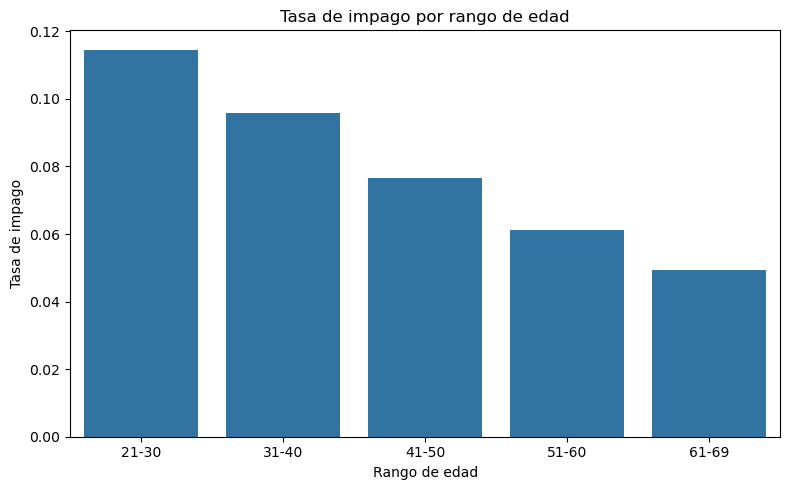

In [34]:
# Analisis de edades en TARGET
application_train['AGE'] = application_train['DAYS_BIRTH'] / -365

application_train['AGE_RANGE'] = pd.cut(application_train['AGE'],
                                        bins=[21,30,40,50,60,69],
                                        labels=['21-30', '31-40','41-50', '51-60', '61-69'])

tasa_por_edad = (
    application_train.groupby('AGE_RANGE')['TARGET']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(data=tasa_por_edad, x='AGE_RANGE', y='TARGET', ax=ax)
ax.set_title('Tasa de impago por rango de edad')
ax.set_xlabel('Rango de edad')
ax.set_ylabel('Tasa de impago')
plt.tight_layout()
plt.savefig('../Reports/figures/06_tasa_impago_rango_edad.png')
plt.show()

In [14]:
# Analisis de nivel educativo vs target con Chi2
from scipy.stats import chi2_contingency

# Con ayuda de crosstab creamos una tabla de frecuencias cruzada entre las dos variables
tabla_contingencia = pd.crosstab(application_train['NAME_EDUCATION_TYPE'], application_train['TARGET'])

stat, p, dof, expected = chi2_contingency(tabla_contingencia)

print(f'Estadístico Chi2: {stat:.2f}')
print(f'P-value: {p:.6f}')
print(f'Grados de libertad: {dof}')


Estadístico Chi2: 1019.21
P-value: 0.000000
Grados de libertad: 4


Con el resultado obtenido con Chi2 donde p-value es menor a 0.001 podemos concluir que hay una clara relación entre la tasa de impago y el nivel educativo

In [4]:
# Analisis de variable de genero
application_train['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [10]:
# Eliminación de valores XNA dado sus pocas observaciones son irrelevantes estadisticamente
# index_xna = application_train[application_train['CODE_GENDER'] == 'XNA'].index

# tasa_genero_impago = application_train[['CODE_GENDER', 'TARGET']].drop(index=index_xna)
# tasa_genero_impago = (tasa_genero_impago.groupby('CODE_GENDER')['TARGET']
#                       .mean()
#                       .reset_index())

tasa_genero_impago = (application_train[application_train['CODE_GENDER'] != 'XNA']
                      .groupby('CODE_GENDER')['TARGET']
                      .mean()
                      .round(2)
                      .reset_index()
                      )

print(f'La tasa de impago por genero es: \n {tasa_genero_impago}')

La tasa de impago por genero es: 
   CODE_GENDER  TARGET
0           F    0.07
1           M    0.10


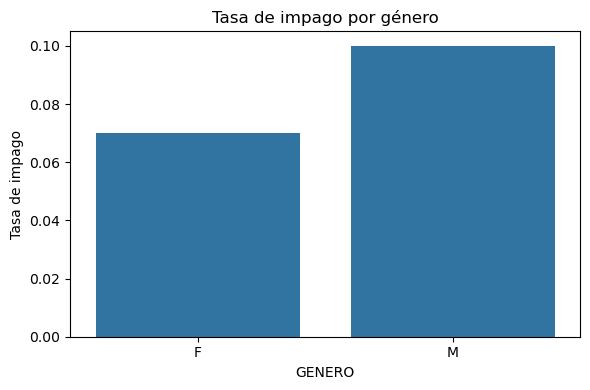

In [16]:
# Visualización de target por genero
fig, ax = plt.subplots(figsize=(6,4))

sns.barplot(data=tasa_genero_impago, x='CODE_GENDER', y='TARGET')
ax.set_title('Tasa de impago por género')
ax.set_xlabel('GENERO')
ax.set_ylabel('Tasa de impago')
plt.tight_layout()
plt.savefig('../Reports/figures/07_impago_genero.png')
plt.show()

In [15]:
# Evaluación con chi2

tabla_contingencia_genero = pd.crosstab(application_train['CODE_GENDER'], application_train['TARGET'])

stat, p, dof, expected = chi2_contingency(tabla_contingencia_genero)

print(f'Estadístico Chi2: {stat:.2f}')
print(f'P-value: {p:.6f}')
print(f'Grados de libertad: {dof}')

Estadístico Chi2: 920.79
P-value: 0.000000
Grados de libertad: 2


Se ha planteado la hipótesis nula de que no existe relación entre la tasa de impago y el genero. Luego de hacer el analisis exploratorio se ha podido visualizar que sí existe una deferencia entre los generos, obteniendo una tasa de impago de 0.07 para el género F y 0.10 para el género M, pudiendo comprobarlo al realizar el test chi2 obteniendo un P-value < 0.001.

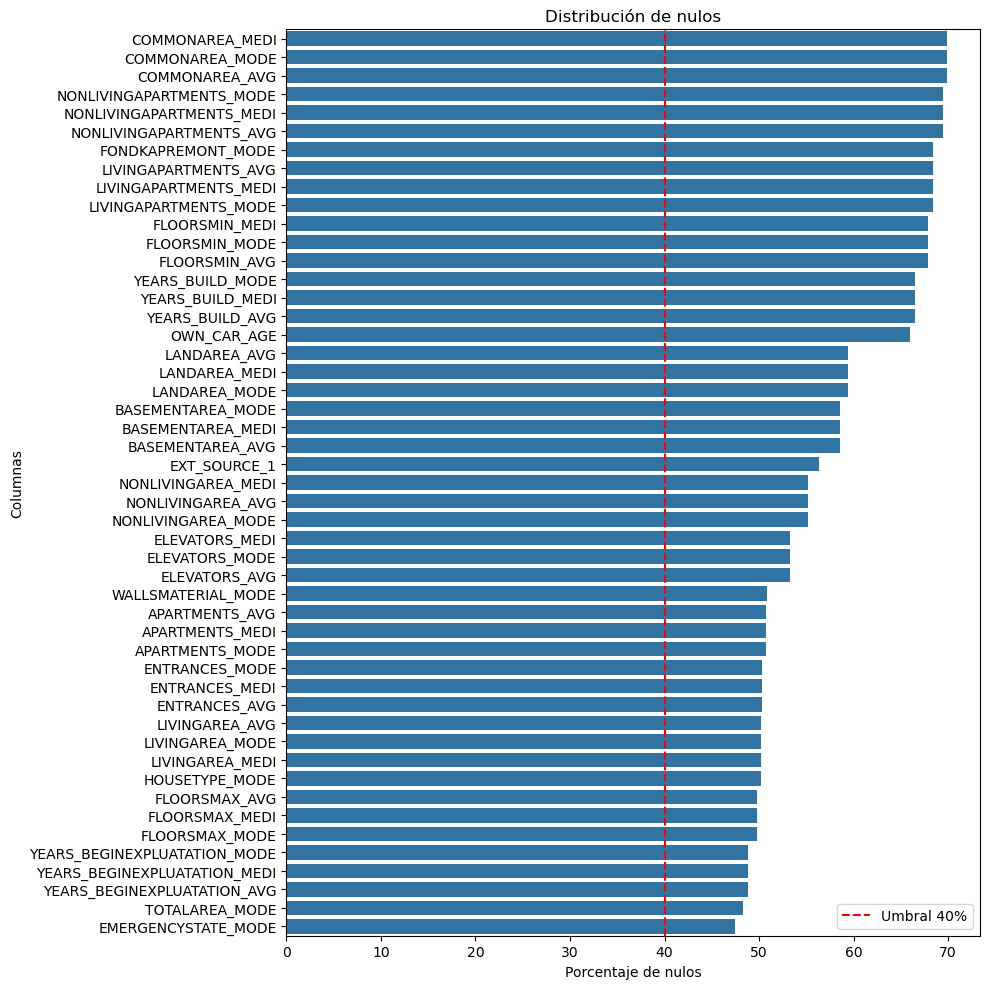

In [37]:
# Visualizacion de distribución de nulos
nulls_above_40 = null_report[null_report['porcentaje'] > 40]

fig, ax = plt.subplots(figsize=(10,10))

sns.barplot(data=nulls_above_40, x='porcentaje', y=nulls_above_40.index)
ax.set_title('Distribución de nulos')
ax.set_ylabel('Columnas')
ax.set_xlabel('Porcentaje de nulos')
ax.axvline(x=40, color='red', linestyle='--', label='Umbral 40%')
ax.legend()
plt.tight_layout()
plt.show()

Con los hallazgos realizados en el análisis exploratorio, el la fase de limpieza se realizará lo siguiente:
- Creación de variables binarias para columnas con más de 40% de nulos, si se establace que los nulos o valores anómalos son MNAR, como DAYS_EMPLOYED.
- Evaluar la eliminación de columnas que no aporten información estadistica significativa tras su evaluación en el modelo.
- Transformaciones de escalas en columnas como AMT_INCOME_TOTAL.